## Logistic regression with ROC curve and ROC AUC score

In [46]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix

In [47]:
X, y= make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
#Create a dummy model with default 0 as output
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [50]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [51]:
## Prediction based on probability
model_prob = model.predict_proba(X_test)
model_prob

array([[3.51112014e-01, 6.48887986e-01],
       [1.32095334e-01, 8.67904666e-01],
       [5.24593248e-01, 4.75406752e-01],
       [1.47364774e-01, 8.52635226e-01],
       [4.45002438e-02, 9.55499756e-01],
       [9.45724448e-01, 5.42755520e-02],
       [7.82234155e-01, 2.17765845e-01],
       [1.78147680e-01, 8.21852320e-01],
       [2.54573593e-01, 7.45426407e-01],
       [6.10423342e-01, 3.89576658e-01],
       [4.93832440e-02, 9.50616756e-01],
       [4.31275944e-01, 5.68724056e-01],
       [9.95203655e-01, 4.79634477e-03],
       [5.13966827e-01, 4.86033173e-01],
       [2.80691771e-01, 7.19308229e-01],
       [7.96254746e-01, 2.03745254e-01],
       [9.23952966e-01, 7.60470342e-02],
       [5.54754830e-02, 9.44524517e-01],
       [1.13056057e-01, 8.86943943e-01],
       [5.28455143e-01, 4.71544857e-01],
       [7.44101488e-03, 9.92558985e-01],
       [7.86898615e-01, 2.13101385e-01],
       [9.51331807e-01, 4.86681931e-02],
       [9.10512490e-01, 8.94875102e-02],
       [2.454074

In [52]:
model_prob = model_prob[:, 1] # Get the probabilities for the positive class

#### ROC AUC (Receiver Operating Characteristic Area Under the Curve) Score
##### ROC AUC score is a  score that measures the performance of a binary classification model. It is calculated by plotting the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings. The area under the ROC curve (AUC) is then computed to provide a single metric that summarizes the model's performance across all thresholds. A higher AUC indicates better model performance, with a value of 1 representing a perfect model and a value of 0.5 indicating a model that performs no better than random chance.

In [53]:
roc_auc_dummy = roc_auc_score(y_test, dummy_model_prob)
roc_auc_model = roc_auc_score(y_test, model_prob)
print(f"ROC AUC Score for Dummy Model: {roc_auc_dummy}")
print(f"ROC AUC Score for Logistic Regression Model: {roc_auc_model}")

ROC AUC Score for Dummy Model: 0.5
ROC AUC Score for Logistic Regression Model: 0.9216159179981912


#### False Positive Rate and True Positive Rate
#### FPR = False Positives / (False Positives + True Negatives)
#### TPR = True Positives / (True Positives + False Negatives)

#### ROC curve is basically the plot of FPR at x-axis vs TPR at y-axis

In [54]:
# Compute ROC curve
fpr_dummy, tpr_dummy, threshold_dummy = roc_curve(y_test, dummy_model_prob)
fpr_model, tpr_model, threshold_model  = roc_curve(y_test, model_prob)

In [55]:
print(fpr_dummy, tpr_dummy)


[0. 1.] [0. 1.]


In [56]:
print(fpr_model, tpr_model)

[0.         0.         0.         0.01075269 0.01075269 0.02150538
 0.02150538 0.03225806 0.03225806 0.04301075 0.04301075 0.05376344
 0.05376344 0.06451613 0.06451613 0.08602151 0.08602151 0.09677419
 0.09677419 0.11827957 0.11827957 0.13978495 0.13978495 0.1827957
 0.1827957  0.21505376 0.21505376 0.22580645 0.22580645 0.30107527
 0.30107527 0.33333333 0.33333333 0.35483871 0.35483871 0.47311828
 0.47311828 0.5483871  0.5483871  0.69892473 0.69892473 0.91397849
 0.91397849 1.        ] [0.         0.00934579 0.42990654 0.42990654 0.4953271  0.4953271
 0.51401869 0.51401869 0.56074766 0.56074766 0.64485981 0.64485981
 0.6728972  0.6728972  0.79439252 0.79439252 0.8411215  0.8411215
 0.85046729 0.85046729 0.86915888 0.86915888 0.87850467 0.87850467
 0.89719626 0.89719626 0.90654206 0.90654206 0.91588785 0.91588785
 0.92523364 0.92523364 0.93457944 0.93457944 0.94392523 0.94392523
 0.96261682 0.96261682 0.97196262 0.97196262 0.98130841 0.98130841
 1.         1.        ]


Text(0.5, 1.0, 'ROC Curve')

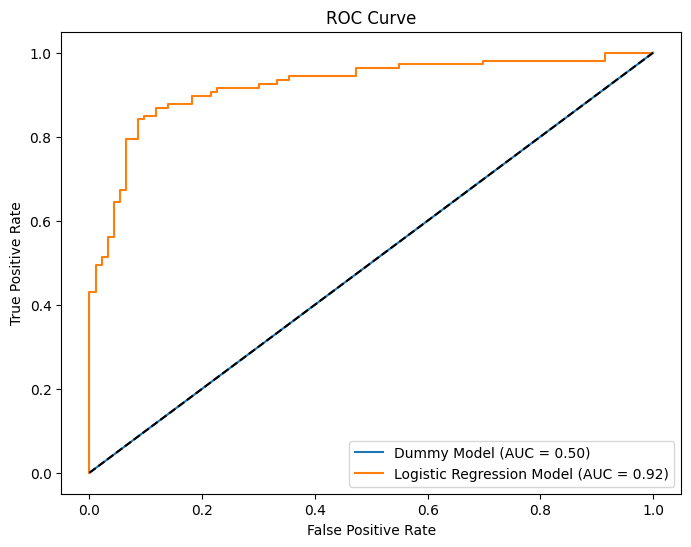

In [57]:
#Pliot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Dummy Model (AUC = {:.2f})'.format(roc_auc_dummy))
plt.plot(fpr_model, tpr_model, label='Logistic Regression Model (AUC = {:.2f})'.format(roc_auc_model))
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

In [58]:
print(f'Thresholds for Dummy Model: {threshold_dummy}')
print(f'Thresholds for Logistic Regression Model: {threshold_model}')

Thresholds for Dummy Model: [inf  0.]
Thresholds for Logistic Regression Model: [       inf 0.99982728 0.93918881 0.93734068 0.89755377 0.89698957
 0.89076141 0.89029953 0.86790467 0.86379686 0.75462    0.74542641
 0.72032391 0.71930823 0.54838445 0.50959859 0.47540675 0.47415768
 0.47154486 0.45282654 0.44759667 0.42968574 0.42350886 0.37052246
 0.34488493 0.29963554 0.2901814  0.2897913  0.26458996 0.21776584
 0.21477485 0.20374525 0.20220372 0.17080913 0.16762497 0.11042754
 0.10687285 0.08746126 0.08597685 0.05417559 0.0539411  0.0130019
 0.00807431 0.00281658]
